# Chromatin Peak to Trough Analysis and Metrics

Summarize the chromatin peak-to-trough ratios for each gene. There will be a few methods we can try. 

1. First, we can plot a distribution of the peak to trough values to get an idea of how we can threshold.

2. Then we will want to determine ways to threshold regions of the chromatin with high cycling chromatin.


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [179]:
gene_ptr = np.load('output/deconvolve_chromatin_2023_12_15/5695_ptr_YPR119W.npy')

In [188]:
genes = pd.read_csv('data/reference_data/geneset_nondub_w_prom_genebodies.csv')\
    .set_index('orf_name')

In [212]:
import glob
import os
import numpy as np

directory_path = 'output/deconvolve_chromatin_2023_12_15/'
pattern = os.path.join(directory_path, '*ptr*')
files_with_ptr = glob.glob(pattern)

# Let's store them in a dictionary indexed by the orf name to start, then we can reorder 
# them into a numpy array
orf_name_ptrs_dic = {}
for filename in files_with_ptr:

    orf_name = filename.split('/')[-1].split('_')[-1].replace('.npy', '')
    gene_ptr = np.load(filename)

    orf_name_ptrs_dic[orf_name] = gene_ptr

print(f"Created a dictionary of PTR arrays of size: {len(orf_name_ptrs_dic)}")
print(f"So, there were { len(genes) - len(orf_name_ptrs_dic)} genes that did not deconvolve")


Created a dictionary of PTR arrays of size: 5402
So, there were 372 genes that did not deconvolve


In [216]:
# Next, we let's make a numpy array ordered by the original genes list

all_ptr_arr = np.zeros((len(genes), gene_ptr.shape[0], gene_ptr.shape[1]))

for index in range(len(genes)):
    
    orf_name = genes.index.values[index]
    
    # Skip if we don't have a deconvolution for the gene
    if orf_name in orf_name_ptrs_dic.keys():
        ptr_img = orf_name_ptrs_dic[orf_name]
        all_ptr_arr[index] = ptr_img

print(f"Created a numpy array of all deconvolved gene PTRs of shape: {all_ptr_arr.shape}")

Created a numpy array of all deconvolved gene PTRs of shape: (5774, 3, 9)


Text(0.5, 1.0, 'Histogram of the\nmaximum PTR for each gene')

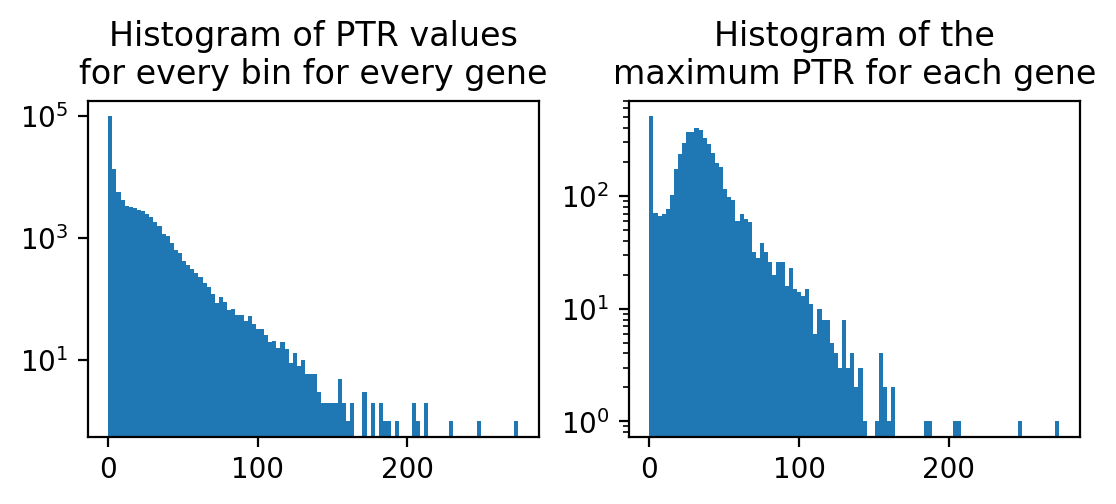

In [236]:
# Let's get an idea of the range of PTR values we have for each gene, this will be
# agnostic to the bin location in the gene
plt.subplot(2, 2, 1)
plt.hist(all_ptr_arr.flatten(), bins=100)
plt.yscale('log')
plt.title("Histogram of PTR values\nfor every bin for every gene")

# We can try selecting the max PTR for each gene and plotting that
plt.subplot(2, 2, 2)
# Let's get an idea of the range of PTR values we have for each gene, this will be
# agnostic to the bin location in the gene
max_ptr_per_gene = all_ptr_arr.max(axis=1).max(axis=1)

plt.hist(max_ptr_per_gene, bins=100)
plt.yscale('log')
plt.title("Histogram of the\nmaximum PTR for each gene")


In [239]:
# Would also like to find genes with a large region of cell cycling chromatin, maybe
# we choose a threshold and plot proportion of the chromatin that is above this threshold?

all_ptr_arr.shape

(5774, 3, 9)

0

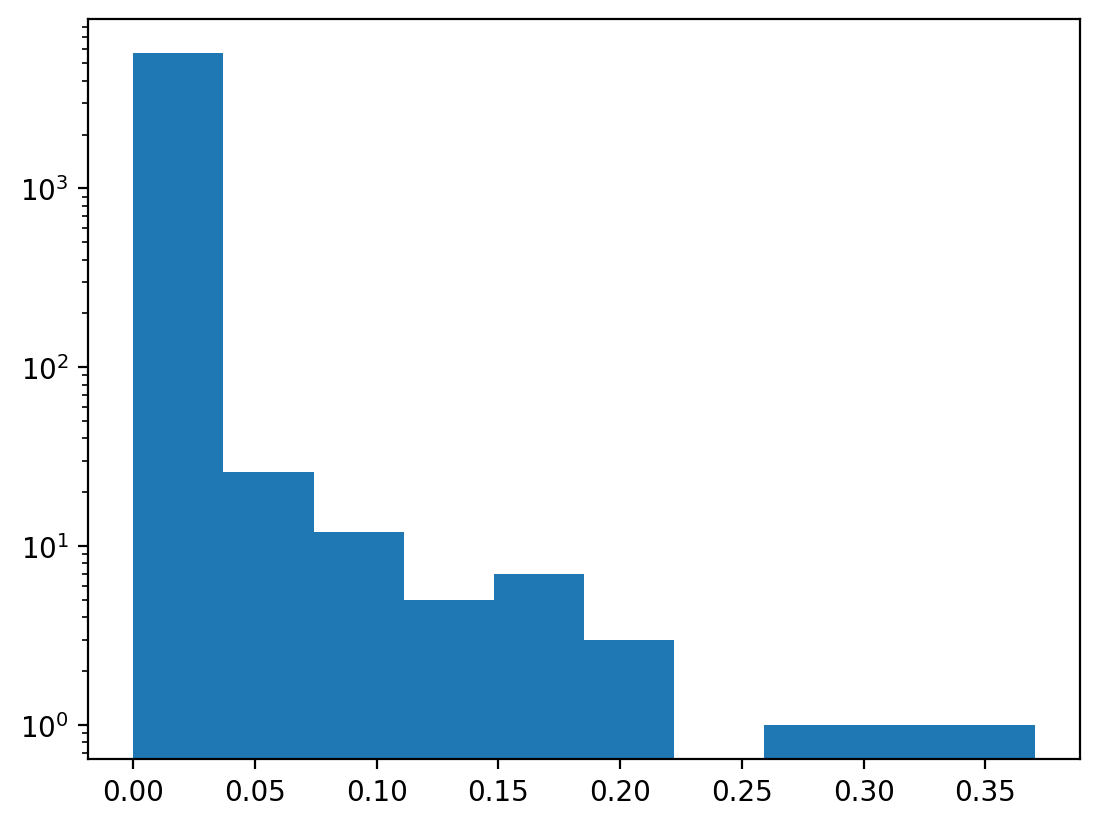

In [251]:
threshold = 100

prop_thresh = (all_ptr_arr > threshold).mean(axis=1).mean(axis=1)

plt.hist(prop_thresh, bins=10)
plt.yscale('log')
0

In [253]:
prop_thresh.argmax()

3837

In [255]:
genes.iloc[3837]

gene                    DIC1
chr                       12
cat                     gene
start                 826977
stop                  827873
strand                     -
classification      Verified
length                   896
TSS                   827996
PAS                 826861.0
manually_curated       False
promoter_start      827996.0
promoter_end        828296.0
gene_body_start     827496.0
gene_body_end       827996.0
Name: YLR348C, dtype: object

The histogram shape around the TSS is: (3, 9)


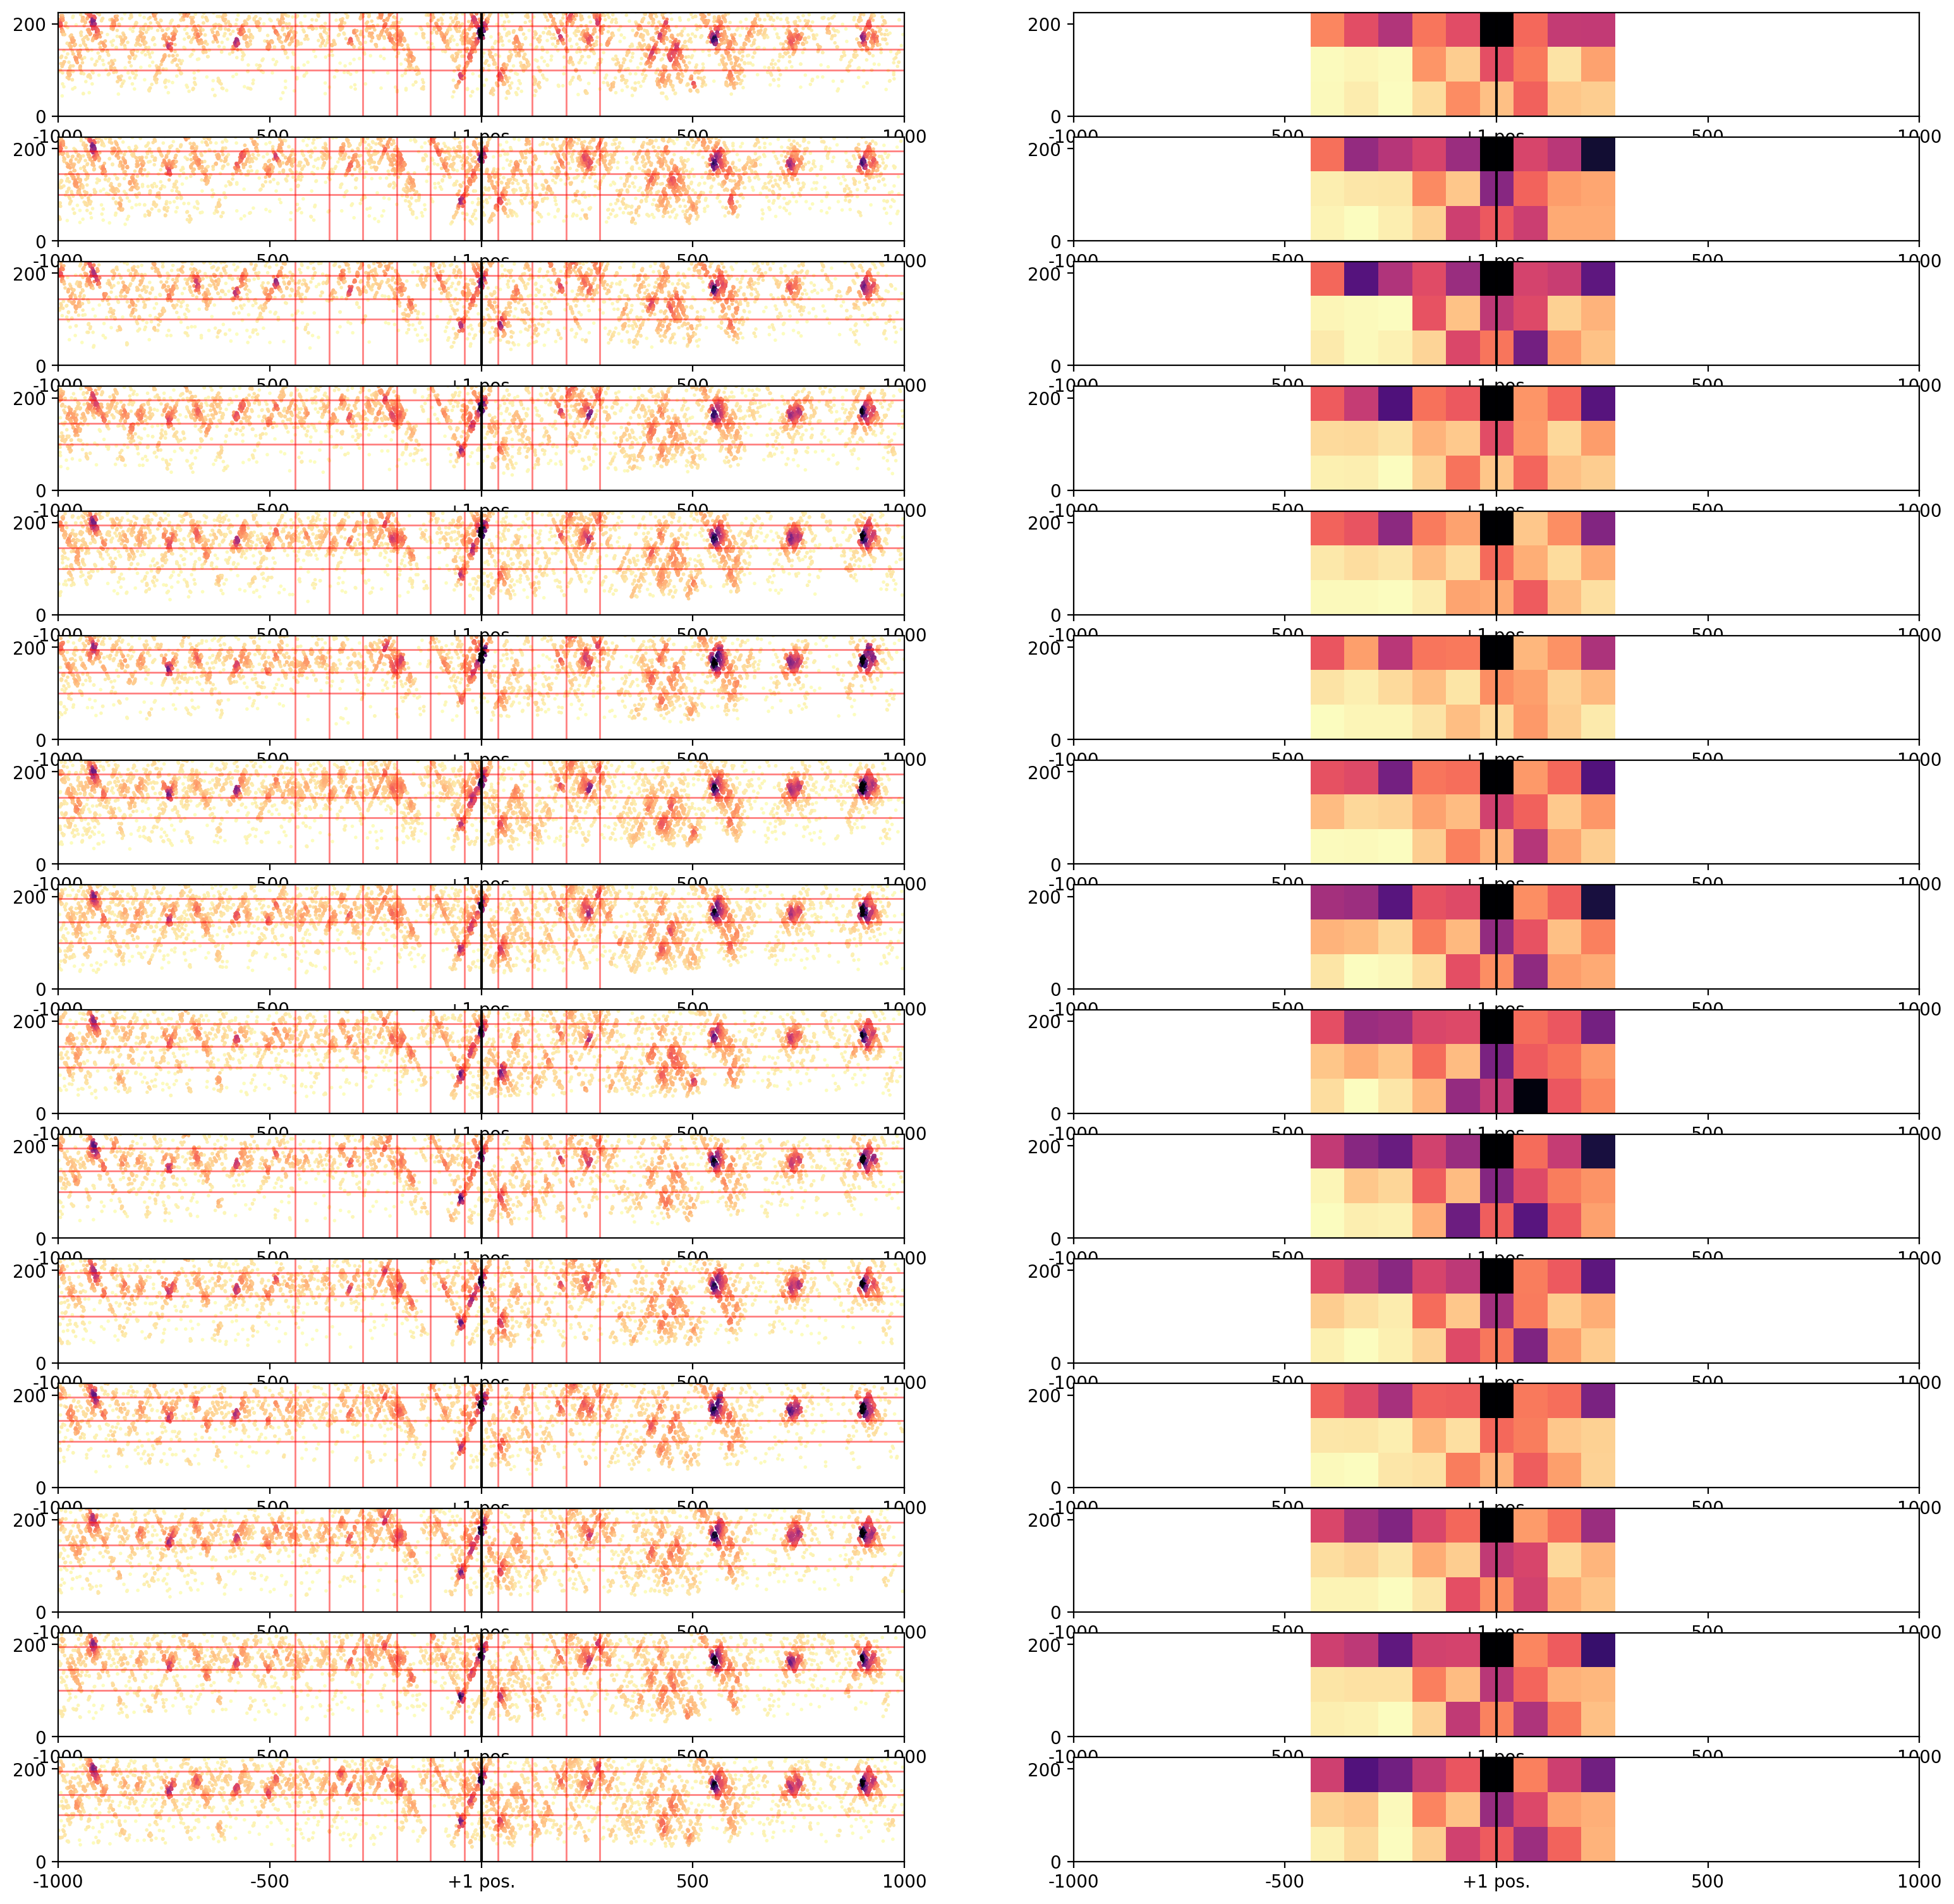

In [257]:
from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()
chromatin_gridder.set_gene('DIC1')
chromatin_gridder.create_bins_per_all_sample()
chromatin_gridder.plot_raw_and_grid()